# SpatialNoise regen test
2025-12-17

VR with help from DLR

## Symphony data 
Updated 

In [1]:
import symphony_data as sd
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

Defining old (current in main) version of spatial noise regen

In [2]:
def getFastNoiseFrames_old(self, numXStixels: int, 
                        numYStixels: int, 
                        numXChecks: int, 
                        numYChecks: int, 
                        chromaticClass: str, 
                        numFrames: int, 
                        stepsPerStixel: int, 
                        seed: int, 
                        frameDwell: int=1,
                        gaussianFilter: bool=False,
                        filterSdStixels: float=1.0):
    """
    Get the frame sequence for the FastNoiseStimulus.
    Parameters:
        numXStixels: number of stixels in the x direction.
        numYStixels: number of stixels in the y direction.
        numXChecks: number of checks in the x direction.
        numYChecks: number of checks in the y direction.
        chromaticClass: chromatic class of the stimulus.
        numFrames: number of frames in the stimulus.
        stepsPerStixel: number of steps per stixel.
        seed: seed for the random number generator.
        frameDwell: number of frames to dwell on each frame.

    Returns:
    frames: 4D array of frames (n_frames, x, y, n_colors).
    """
    # Seed the random number generator.
    np.random.seed( seed )

    # First, generate the larger grid of stixels.
    if (chromaticClass == 'BY'):
        tfactor = 2
    elif (chromaticClass == 'RGB'):
        tfactor = 3
    else: # Black/white checks
        tfactor = 1

    # Get the size of the time dimension; expands for RGB, etc.
    tsize = np.ceil(numFrames*tfactor/frameDwell).astype(int)
    
    if (tfactor == 2 and (tsize % 2) != 0):
        tsize += 1
    
    # Generate the random grid of stixels.
    gridValues = np.random.rand(tsize, numXStixels*numYStixels)
    gridValues = np.reshape(gridValues, (tsize, numXStixels, numYStixels))
    gridValues = np.transpose(gridValues, (0, 2, 1))
    gridValues = np.round(gridValues)
    gridValues = (2*gridValues-1).astype(np.float32) # Convert to contrast

    # Filter the stixels if indicated.
    if gaussianFilter:
        for i in range(tsize):
            # frame_tmp = gaussian_filter(gridValues[i,:,:], sigma=filterSdStixels, order=0, mode='wrap', radius=np.ceil(2*filterSdStixels).astype(int))
            frame_tmp = gaussian_filter(gridValues[i,:,:], sigma=filterSdStixels, order=0, mode='wrap')
            gridValues[i,:,:] = 0.5*frame_tmp/np.std(frame_tmp)
        gridValues[gridValues > 1.0] = 1.0
        gridValues[gridValues < -1.0] = -1.0

    # Translate to the full grid
    fullGrid = np.zeros((tsize,numYStixels*stepsPerStixel,numXStixels*stepsPerStixel), dtype=np.float32)
    # fullGrid = np.zeros((tsize,numYStixels*stepsPerStixel,numXStixels*stepsPerStixel), dtype=np.uint8)

    for k in range(numYStixels*stepsPerStixel):
        yindex = math.floor(k/stepsPerStixel)
        for m in range(numXStixels*stepsPerStixel):
            xindex = math.floor(m/stepsPerStixel)
            fullGrid[:, k, m] = gridValues[:, yindex, xindex]

    # Generate the motion trajectory of the larger stixels.
    np.random.seed( seed ) # Re-seed the number generator

    # steps = np.round( (stepsPerStixel-1) * np.random.rand(tsize, 2) )
    steps = np.round( (stepsPerStixel-1) * np.random.rand(tsize, 2) )
    steps[:,0] = (stepsPerStixel-1) - steps[:,0]
    # steps = (stepsPerStixel-1) - np.round( (stepsPerStixel-1) * np.random.rand(tsize, 2) )
    # Get the frame values for the finer grid.
    # frameValues = np.zeros((tsize,numYChecks,numXChecks),dtype=np.uint8)
    frameValues = np.zeros((tsize,numYChecks,numXChecks),dtype=np.float32)
    for k in range(tsize):
        x_offset = steps[math.floor(k/tfactor), 0].astype(int)
        y_offset = steps[math.floor(k/tfactor), 1].astype(int)
        frameValues[k,:,:] = fullGrid[k, y_offset : numYChecks+y_offset, x_offset : numXChecks+x_offset]

    # Create your output stimulus. (t, y, x, color)
    stimulus = np.zeros((np.ceil(tsize/tfactor).astype(int),numYChecks,numXChecks,3), dtype=np.float32)

    # Get the pixel values into the proper color channels
    if (chromaticClass == 'BY'):
        stimulus[:,:,:,0] = frameValues[0::2,:,:]
        stimulus[:,:,:,1] = frameValues[0::2,:,:]
        stimulus[:,:,:,2] = frameValues[1::2,:,:]
    elif (chromaticClass == 'RGB'):
        stimulus[:,:,:,0] = frameValues[0::3,:,:]
        stimulus[:,:,:,1] = frameValues[1::3,:,:]
        stimulus[:,:,:,2] = frameValues[2::3,:,:]
    else: # Black/white checks
        stimulus[:,:,:,0] = frameValues
        stimulus[:,:,:,1] = frameValues
        stimulus[:,:,:,2] = frameValues
    # return stimulus

    # Deal with the frame dwell.
    if frameDwell > 1:
        stim = np.zeros((numFrames,numYChecks,numXChecks,3), dtype=np.float32)
        for k in range(numFrames):
            idx = np.floor(k / frameDwell).astype(int)
            stim[k,:,:,:] = stimulus[idx,:,:,:]
        return stim
    else:
        return stimulus

## Metadata for particular epoch

In [3]:
exp_name = '20250514C'
datafile_name = 'data001'
e_idx = 9

In [4]:
param_names = ['stimulusClass', 'chromaticClass', 'noiseClass', 'frameDwell', 'stepDuration', 'gridSize', 'uniqueTime', 'repeatTime',
                'numXChecks', 'numYChecks', 'numFrames', 'numXStixels', 'numYStixels', 'stixelSize', 'stepsPerStixel', 'seed', 'stimTime','pixelDensity']

D = sd.Dataset(exp_name)
protocol = D.M.search_data_file('SpatialNoise', file_name=datafile_name)
params, unique_params = D.M.get_stimulus_parameters(protocol, param_names=param_names)

## Regenerate using old method
Use the old (current in main) verrsion of spatial noise regen

In [5]:
# Only regen first 100 frames for comparison
num_frames = 100
S = sd.Stimulus()
old_regen_frames = getFastNoiseFrames_old(
    S,
    int(params['numXStixels'][e_idx]),
    int(params['numYStixels'][e_idx]),
    int(params['numXChecks'][e_idx]),
    int(params['numYChecks'][e_idx]),
    params['chromaticClass'][e_idx],
    num_frames,
    int(params['stepsPerStixel'][e_idx]),
    int(params['seed'][e_idx]),
    int(params['frameDwell'][e_idx]),
    gaussianFilter=False
)

## Regenerate using updated method

In [6]:
fixed_regen_frames = S.getFastNoiseFrames(
    int(params['numXStixels'][e_idx]),
    int(params['numYStixels'][e_idx]),
    int(params['numXChecks'][e_idx]),
    int(params['numYChecks'][e_idx]),
    params['chromaticClass'][e_idx],
    num_frames,
    int(params['stepsPerStixel'][e_idx]),
    int(params['seed'][e_idx]),
    int(params['frameDwell'][e_idx]),
    gaussianFilter=False
)

## Ground Truth stim frames
Load stim frames regenerated with Stage in pixel space thanks to @DRezeanu method

In [22]:
def load_true_frames(str_mat, ds_shape, n_pre_frames=16):
    d_mat = loadmat(str_mat)
    n_frames = d_mat['frames_out'].shape[1]
    s_frames = np.zeros((n_frames, 1140, 1824, 3))
    for i in range(n_frames):
        s_frames[i,:,:,:] = d_mat['frames_out'][0,i]
    s_frames = s_frames.astype(np.float32) / 255.0

    # Clip preframes
    s_frames = s_frames[n_pre_frames:]
    # idk why stage regen is y-flipped, let's assume yflipping is right thing to do
    s_frames = s_frames[:,::-1,...]

    print(f'Loaded {s_frames.shape} shape true stimulus frames from {str_mat}')

    # Downsample to ds_shape
    ds_frames = np.zeros((s_frames.shape[0], ds_shape[0], ds_shape[1], 3), dtype=np.float32)
    for i in range(s_frames.shape[0]):
        ds_frames[i,:,:,:] = cv2.resize(
            s_frames[i,:,:,:], 
            (ds_shape[1], ds_shape[0]), interpolation=cv2.INTER_AREA)
    print(f'Downsampled true stimulus frames to {ds_frames.shape}')
    return ds_frames

In [23]:
str_mat = 'epoch10_20250514C_100frames.mat'
ds_shape = fixed_regen_frames.shape[1:3]
true_frames = load_true_frames(str_mat, ds_shape)

Loaded (84, 1140, 1824, 3) shape true stimulus frames from epoch10_20250514C_100frames.mat
Downsampled true stimulus frames to (84, 127, 203, 3)


## Comparison

In [35]:
def plot_frame_comparison(true_frames, regen_frames, str_regen_title, i_frame = 0):
    f, axs = plt.subplots(ncols=3, figsize=(20,5))
    ls_f = [true_frames, regen_frames]
    ls_titles = ['Stage regen (Channel 0)', str_regen_title]
    
    for i in range(2):
        ax = axs[i]
        f = ls_f[i][i_frame]
        f = f[...,0]
        im=ax.imshow(f, aspect='auto')
        ax.set_title(ls_titles[i])
        plt.colorbar(im, ax=ax)

    ax = axs[2]
    f = ls_f[0][i_frame] - ls_f[1][i_frame]
    f = f[...,0]
    r = np.corrcoef(ls_f[0][i_frame].flatten(), ls_f[1][i_frame].flatten())[0,1]
    im=ax.imshow(f, cmap='viridis', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Difference (r={r:.2f})')

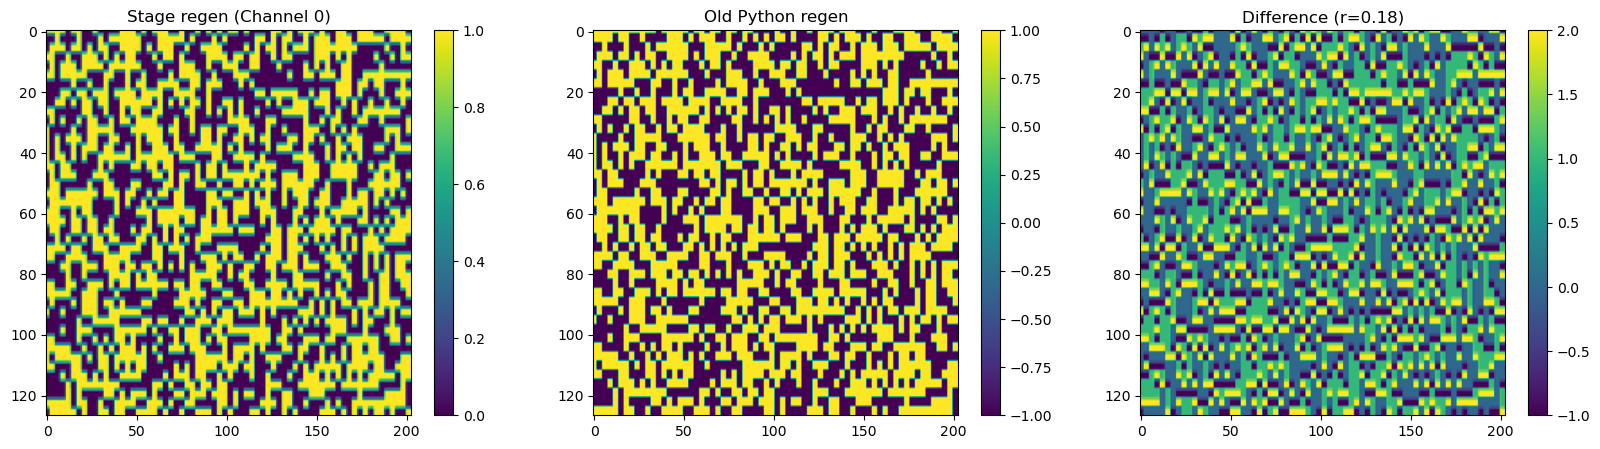

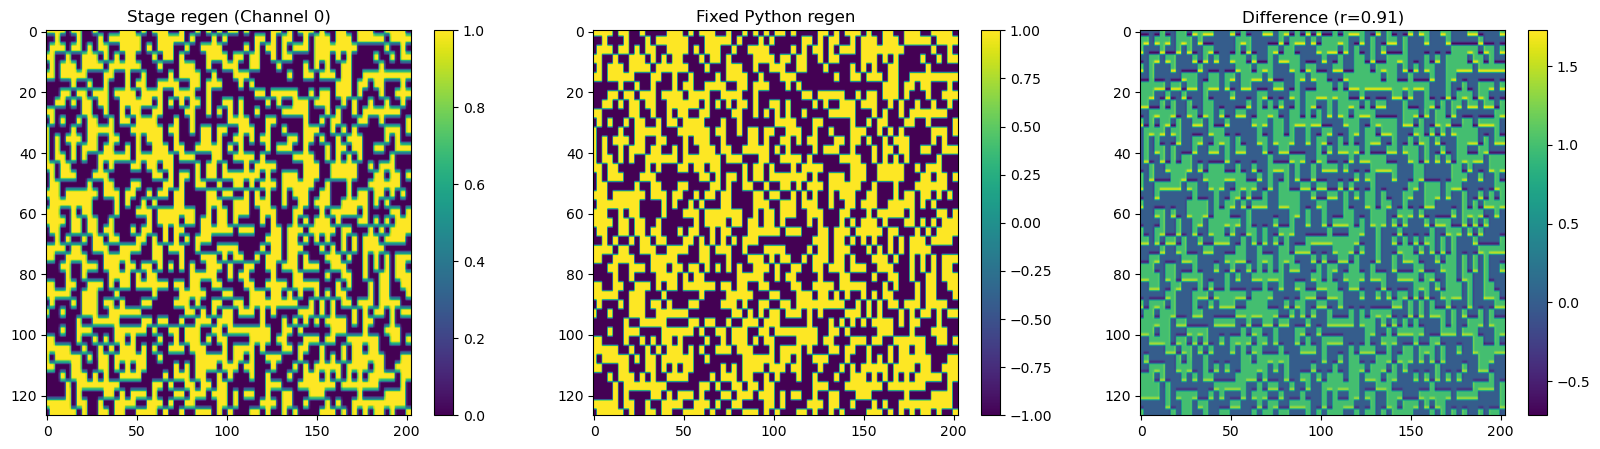

In [36]:
plot_frame_comparison(true_frames, old_regen_frames, 'Old Python regen', 0)
plot_frame_comparison(true_frames, fixed_regen_frames, 'Fixed Python regen', 0)

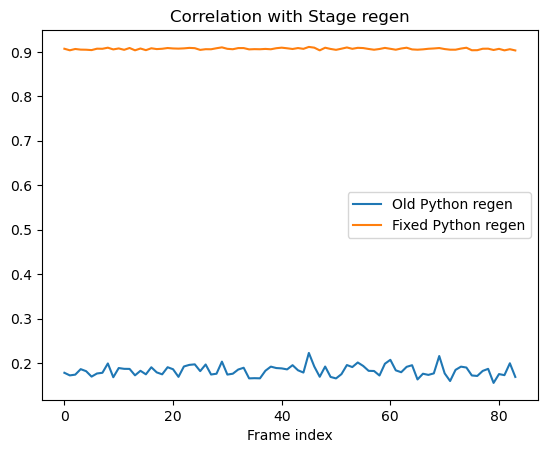

In [38]:
ls_old_corrs = []
ls_fixed_corrs = []
for t in range(true_frames.shape[0]):
    old_r = np.corrcoef(true_frames[t].flatten(), old_regen_frames[t].flatten())[0,1]
    fixed_r = np.corrcoef(true_frames[t].flatten(), fixed_regen_frames[t].flatten())[0,1]
    ls_old_corrs.append(old_r)
    ls_fixed_corrs.append(fixed_r)

plt.plot(ls_old_corrs, label='Old Python regen')
plt.plot(ls_fixed_corrs, label='Fixed Python regen')
plt.xlabel('Frame index')
plt.title('Correlation with Stage regen')
plt.legend()

Even with the fix regen is imperfect, I believe because we regen in a downsampled (127, 203) space which does not evenly scale up to full (1140, 1824) pixel space.